In [10]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer

scaler = MinMaxScaler()

In [2]:
# Find unique entries
unique_path = r"../data/grand_scraper_folder/unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

In [42]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
images_raw = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_raw = []
tokendata_raw = []

#Folder with folders of images:
base_folder = r"../data/scrandle_padded_low_res_data"
#Meta data folders(yes, a bit inefficient. CHANGE LATER):
meta_folder = r"../data/grand_scraper_folder/scrandle_data"
current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    #print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    images_raw.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

    if current_folder != date:
        current_folder = date
        meta_path = os.path.join(meta_folder, date, "meta.csv")
        meta_intermediate = pd.read_csv(meta_path)
        meta_tokens = pd.read_csv(meta_path,sep=",").fillna("")
        
        
    entry_row = meta_intermediate.loc[meta_intermediate["image_name"] == image_placement]
    metadata_raw.append({
                "price": entry_row["price"],
                "rating": entry_row["rating"],
                "year": entry_row["year"],
                "date": entry_row["date"],
                "image_name": entry_row["image_name"],
                "title": entry_row["title"],
                "subtitle": entry_row["subtitle"],
                "club": entry_row["club"],
                "country": entry_row["country"],
            })
    tokendata_raw.append(f"{entry_row["title"].iloc[0]} {entry_row["subtitle"].iloc[0]} {entry_row["country"].iloc[0]} {entry_row["club"].iloc[0]}")

In [66]:
ratings = []
for i in range(len(metadata_raw)):
    ratings += metadata_raw[i]["rating"].to_list()
ratings = torch.tensor(ratings) / 100

prices = []
for i in range(len(metadata_raw)):
    prices += metadata_raw[i]["price"].to_list()
prices = np.array(prices)
nan_mask = prices != prices
prices[nan_mask] = 0.0
prices = torch.tensor(scaler.fit_transform(prices.reshape(-1, 1)).ravel())

vectorizer = CountVectorizer()
tokens_csr = vectorizer.fit_transform(tokendata_raw)
tokens = torch.tensor(tokens_csr.toarray(), dtype=torch.float32) / 3.0

images = np.stack([img["RGB"] for img in images_raw]).astype(np.float32)
images = torch.from_numpy(images) / 255.0
images = images.permute(0,3,1,2)

In [78]:
tokens_csr

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 39939 stored elements and shape (4827, 3650)>

In [ ]:
class ImagePriceRatingDataset(Dataset):
    def __init__(self, ratings, images, prices, tokens):
        if not (len(ratings) == len(images) == len(prices) == len(tokens)):
            raise ValueError("ratings, images, prices and tokens must have equal length")
        self.ratings = ratings
        self.images = images
        self.prices = prices
        self.tokens = tokens

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.images[idx], self.prices[idx], self.tokens[idx], self.ratings[idx]

n_tokens = tokens.shape[1]
class ImagePriceModel(nn.Module):
    def __init__(self, token_dim=n_tokens):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        image_branch = resnet50(weights=weights)
        self.image_branch = nn.Sequential(*list(image_branch.children())[:-1])  # 2048 features

        self.price_branch = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
        )

        self.token_branch = nn.Sequential(
            nn.Linear(token_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 128),
            nn.ReLU(),
        )

        joint_dim = 2048 + 16 + 128
        self.head = nn.Sequential(
            nn.Linear(joint_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, image, price, token):
        img_feat = self.image_branch(image).flatten(1)      # [B, 2048]
        price_feat = self.price_branch(price)                # [B, 16]
        token_feat = self.token_branch(token)                # [B, 128]
        x = torch.cat([img_feat, price_feat, token_feat], dim=1)
        return self.head(x)

dataset = ImagePriceRatingDataset(ratings, images, prices, tokens)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")

model = ImagePriceModel().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(10):
    model.train()
    total_loss = 0.0

    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")

Using Device: cuda
epoch 1: loss=0.1816
epoch 2: loss=0.1298
epoch 3: loss=0.1084


In [101]:
print("Initating Fine Grid Level 1...")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# training loop
for epoch in range(10):
    model.train()
    total_loss = 0.0

    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")
print("Fine Grid Level 1: Complete")


print("Initating Fine Grid Level 2...")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

# training loop
for epoch in range(10):
    model.train()
    total_loss = 0.0

    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")
print("Fine Grid Level 2: Complete")


print("Initating Fine Grid Level 3...")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-6)

# training loop
for epoch in range(10):
    model.train()
    total_loss = 0.0

    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")
print("Fine Grid Level 3: Complete")


print("Initating Fine Grid Level 4...")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-7)

# training loop
for epoch in range(10):
    model.train()
    total_loss = 0.0

    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_temp = images_loaded.float().to(device)
        prices_temp = prices_loaded.float().unsqueeze(1).to(device)
        tokens_temp = tokens_loaded.float().to(device)
        ratings_temp = ratings_loaded.float().unsqueeze(1).to(device)

        preds = model(images_temp, prices_temp, tokens_temp)
        loss = criterion(preds, ratings_temp)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}")
print("Fine Grid Level 4: Complete")

Initating Fine Grid Level 1...
epoch 1: loss=0.0645
epoch 2: loss=0.0575
epoch 3: loss=0.0546
epoch 4: loss=0.0517
epoch 5: loss=0.0487
epoch 6: loss=0.0468
epoch 7: loss=0.0450
epoch 8: loss=0.0448
epoch 9: loss=0.0432
epoch 10: loss=0.0427
Fine Grid Level 1: Complete
Initating Fine Grid Level 2...
epoch 1: loss=0.0403
epoch 2: loss=0.0391
epoch 3: loss=0.0394
epoch 4: loss=0.0386
epoch 5: loss=0.0386
epoch 6: loss=0.0379
epoch 7: loss=0.0374
epoch 8: loss=0.0380
epoch 9: loss=0.0369
epoch 10: loss=0.0375
Fine Grid Level 2: Complete
Initating Fine Grid Level 3...
epoch 1: loss=0.0365
epoch 2: loss=0.0369
epoch 3: loss=0.0370
epoch 4: loss=0.0368
epoch 5: loss=0.0367
epoch 6: loss=0.0366
epoch 7: loss=0.0359
epoch 8: loss=0.0361
epoch 9: loss=0.0355
epoch 10: loss=0.0371
Fine Grid Level 3: Complete
Initating Fine Grid Level 4...
epoch 1: loss=0.0373
epoch 2: loss=0.0367
epoch 3: loss=0.0363
epoch 4: loss=0.0357
epoch 5: loss=0.0363
epoch 6: loss=0.0363
epoch 7: loss=0.0370
epoch 8: los

In [24]:
torch.save(model.state_dict(), "model_weights")

In [102]:
model.eval()

preds_train = []
trues_train = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in train_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_train.append(outputs.cpu())
        trues_train.append(ratings_loaded.cpu())

preds_train = torch.cat(preds_train).numpy()
trues_train = torch.cat(trues_train).numpy()


preds_test = []
trues_test = []

with torch.no_grad():
    for images_loaded, prices_loaded, tokens_loaded, ratings_loaded in test_loader:
        images_loaded = images_loaded.to(device)
        prices_loaded = prices_loaded.float().unsqueeze(1).to(device)
        tokens_loaded = tokens_loaded.to(device)
        outputs = model(images_loaded, prices_loaded, tokens_loaded).squeeze(1)

        preds_test.append(outputs.cpu())
        trues_test.append(ratings_loaded.cpu())

preds_test = torch.cat(preds_test).numpy()
trues_test = torch.cat(trues_test).numpy()


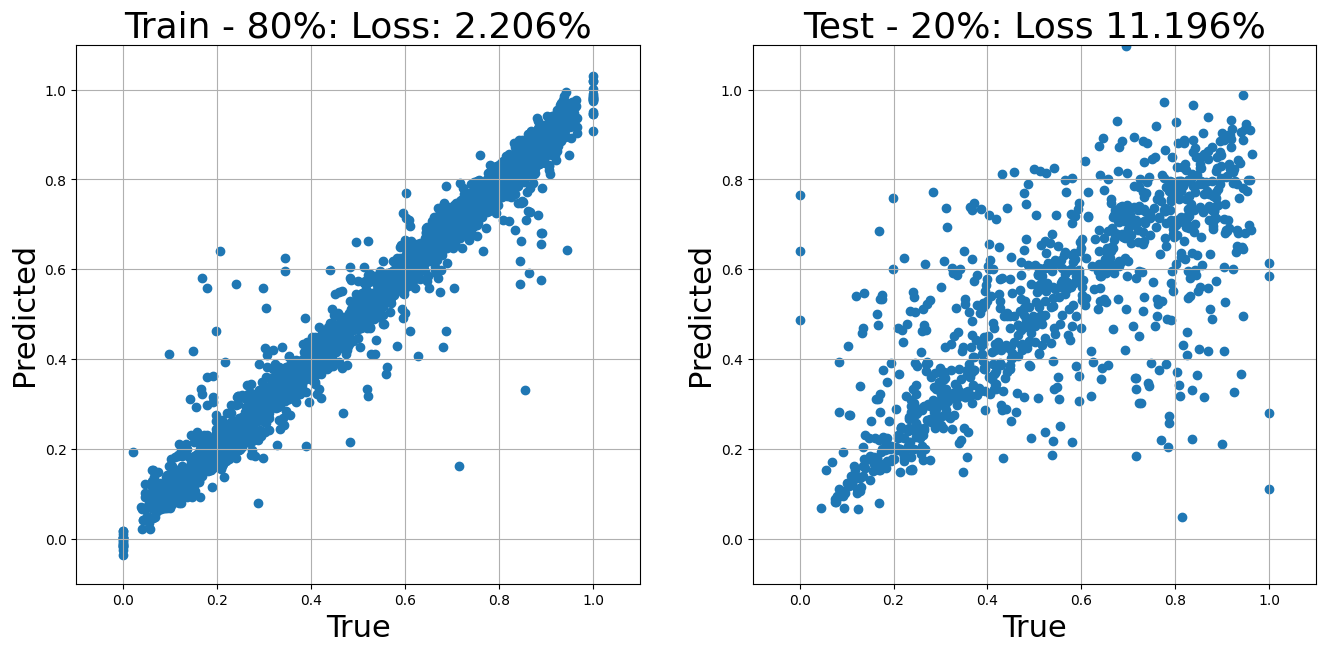

In [103]:
mask = trues_train != 0.0
loss_train = np.mean(np.abs(preds_train - trues_train))

fig, ax = plt.subplots(1,2, figsize=(16,7))
ax[0].scatter(trues_train, preds_train)
ax[0].set_xlim(-0.1,1.1)
ax[0].set_ylim(-0.1,1.1)
ax[0].set_xlabel("True", fontsize=22)
ax[0].set_ylabel("Predicted", fontsize=22)
ax[0].set_title(f"Train - 80%: Loss: {loss_train*100:.3f}%", fontsize=26)
ax[0].grid()

mask = trues_test != 0.0
loss_test = np.mean(np.abs(preds_test - trues_test))

ax[1].scatter(trues_test, preds_test)
ax[1].set_xlim(-0.1,1.1)
ax[1].set_ylim(-0.1,1.1)
ax[1].set_xlabel("True", fontsize=22)
ax[1].set_ylabel("Predicted", fontsize=22)
ax[1].set_title(f"Test - 20%: Loss {loss_test*100:.3f}%", fontsize=26)
ax[1].grid()
plt.show()